In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
csv_path = "used_cars_mock.xls"
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head(100)

Shape: (10000, 10)


,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999
1,2,Fiat,Model B,2030,NaN,Hybrid,Automatic,1,1,19076
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0
...,...,...,...,...,...,...,...,...,...,...
95,96,Hyundai,Model C,2022,50774.0,Hybrid,Automatic,6,30,22691
96,97,Toyota,Model C,2022,24250.0,Petrol,Manual,4,20,21213
97,98,Fiat,Model C,2021,59778.0,Petrol,Manual,11,30,10017
98,99,BMW,Model C,2002,250000.0,Petrol,Automatic,11,1,500


In [ ]:
print(df)

In [ ]:
profile = [R]

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_id        10000 non-null  int64  
 1   brand         10000 non-null  object 
 2   model         10000 non-null  object 
 3   year          10000 non-null  int64  
 4   mileage       9694 non-null   float64
 5   fuel_type     10000 non-null  object 
 6   transmission  10000 non-null  object 
 7   sale_month    10000 non-null  int64  
 8   zip_prefix    10000 non-null  int64  
 9   price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


In [28]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].unique())

brand ['Honda' 'Fiat' 'Audi' 'VW' 'Dacia' 'BMW' 'Ford' 'Mercedes' 'Toyota'
 'Hyundai']
model ['Model A' 'Model B' 'Model C']
fuel_type ['Petrol' 'Hybrid' 'XYZ' 'Diesel']
transmission ['Manual' 'Automatic']


In [29]:
df.describe(include='all')

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
count,10000.00000,10000,10000,10000.000000,9694.000000,10000,10000,10000.000000,10000.00000,10000.000000
unique,NaN,10,3,NaN,NaN,4,2,NaN,NaN,NaN
top,NaN,Toyota,Model B,NaN,NaN,Petrol,Automatic,NaN,NaN,NaN
freq,NaN,1498,3441,NaN,NaN,6969,5957,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,2019.804700,62036.526718,NaN,NaN,6.738100,15.42200,15278.148600
std,2886.89568,NaN,NaN,6.324884,71546.816912,NaN,NaN,3.581451,11.57261,13725.370724
min,1.00000,NaN,NaN,2000.000000,-500.000000,NaN,NaN,1.000000,1.00000,0.000000
25%,2500.75000,NaN,NaN,2018.000000,7771.000000,NaN,NaN,4.000000,1.00000,6761.500000
50%,5000.50000,NaN,NaN,2022.000000,35781.500000,NaN,NaN,7.000000,20.00000,15852.000000
75%,7500.25000,NaN,NaN,2025.000000,87767.500000,NaN,NaN,10.000000,30.00000,23125.000000


In [30]:
#possible wrong values check
for col in df.columns:
    col_low = col.lower()

    if "year" in col_low:
        print(f"\nInvalid years in {col}:")
        print(df[(df[col] < 1990) | (df[col] > 2026)][[col]])

    if "price" in col_low or col_low == "sp":
        print(f"\nZero/negative values in {col}:")
        print(df[df[col] <= 0][[col]])

    if "km" in col_low or "driven" in col_low or "mileage" in col_low:
        print(f"\nNegative values in {col}:")
        print(df[df[col] < 0][[col]])


Invalid years in year:
   year
1  2030

Negative values in mileage:
   mileage
2   -500.0

Zero/negative values in price:
   price
4      0


In [31]:
df.drop_duplicates()

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999
1,2,Fiat,Model B,2030,NaN,Hybrid,Automatic,1,1,19076
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,Toyota,Model A,2025,13572.0,Petrol,Manual,5,30,23215
9996,9997,Toyota,Model B,2025,0.0,Petrol,Manual,7,1,26088
9997,9998,Fiat,Model A,2025,0.0,Petrol,Manual,12,30,20601
9998,9999,Toyota,Model B,2021,53390.0,Petrol,Manual,12,10,10563


In [32]:
df.isnull().sum()

car_id            0
brand             0
model             0
year              0
mileage         306
fuel_type         0
transmission      0
sale_month        0
zip_prefix        0
price             0
dtype: int64

#### **Mileage has 306 NAN values**

## **Data cleaning-**
- **The price column contained invalid values like 0 and unrealistic high values (e.g., 999999). These were replaced using brand-wise comparison to ensure realistic pricing.**
- **negative relationship between car age and price, indicating that older vehicles tend to have lower prices**
- **Negative mileage values are invalid for analysis, so Replace negative and zero mileage with median of.**
- **"xyz" is an invalid category in fuel_type , therefore , removed**
- **here car age is -4 and year is 2030 , negative car age and future manifacturing year invalid data**

### **FUEL_TYPE :**

In [33]:
df['fuel_type'].value_counts()

fuel_type
Petrol    6969
Diesel    2050
Hybrid     980
XYZ          1
Name: count, dtype: int64

### **"xyz" is an invalid category in fuel_type**

In [34]:
df = df[df['fuel_type'] != 'XYZ']

In [35]:
df['fuel_type'].value_counts()

fuel_type
Petrol    6969
Diesel    2050
Hybrid     980
Name: count, dtype: int64

## year :

#### here car age is -4  and year is 2030 , negative car age and future manifacturing year invalid data 

In [36]:
df = df[df['year'] <= 2025]

In [37]:
df[df['year'] > 2025]

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price


## **PRICE :**

In [38]:
df["price"].describe()

count      9998.000000
mean      15277.483297
std       13726.661358
min           0.000000
25%        6760.500000
50%       15847.000000
75%       23127.000000
max      999999.000000
Name: price, dtype: float64

In [39]:
df.shape

(9998, 10)

In [40]:
df["price"].describe()

count      9998.000000
mean      15277.483297
std       13726.661358
min           0.000000
25%        6760.500000
50%       15847.000000
75%       23127.000000
max      999999.000000
Name: price, dtype: float64

In [41]:
df[df['price'] <= 0]['price'].value_counts()

price
0    1
Name: count, dtype: int64

In [42]:
df[df['price'] <= 0] # checked

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0


In [43]:
df["price"].describe()

count      9998.000000
mean      15277.483297
std       13726.661358
min           0.000000
25%        6760.500000
50%       15847.000000
75%       23127.000000
max      999999.000000
Name: price, dtype: float64

#### **minimum value of price was = 0, which is logically invalid as a car cannot have zero cost. Therefore, such entries were identified and removed from the dataset.**

In [44]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [45]:
outliers = df[(df['price'] < lower) | (df['price'] > upper)]
outliers.sort_values(by='price')

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999


##### high price (999999) =  extreme value, it may represent a rare or premium listing. Therefore, instead of directly removing it, further analysis such as brand-wise comparison. this extreme value is replaced with the brands avg price. 

In [46]:
df.loc[(df['brand'] == 'Honda') & (df['price'] == df['price'].max()), 'price'] = df[df['brand']=='Honda']['price'].median()

In [47]:
df['price'] = df['price'].replace(0, df['price'].median())

In [48]:
df.shape

(9998, 10)

In [49]:
df["price"].describe()

count     9998.000000
mean     15180.619674
std       9559.906214
min        500.000000
25%       6763.250000
50%      15844.750000
75%      23123.750000
max      38875.000000
Name: price, dtype: float64

##### In the real world, many cars actually cost less than 5,000 (especially older models). so For these specific errors, replaced the price with the Median Price of cars from the same Year and with a similar Mileage range

In [50]:
# Step 0: Convert price to float
df['price'] = df['price'].astype(float)

#  Create mileage bins
bins = [0, 30000, 100000, np.inf]
labels = ['Low', 'Medium', 'High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# Step 2: Define error condition or erroneous data
error_condition = (df['price'] < 5000) & (df['year'] > 2018)

# Step 3: Calculate median price based on (year + mileage_bin)
median_price = df.groupby(['year', 'mileage_bin'], observed=True)['price'].transform('median')

# Step 4: Apply imputation only on error rows
df.loc[error_condition, 'price'] = median_price[error_condition]

# Step 5: Fallback using year media - If price is still missing, fill it using the median price of cars from the same year
df['price'] = df['price'].fillna(df.groupby('year')['price'].transform('median'))
df['price'] = df['price'].fillna(df['price'].median())

In [51]:
df.shape

(9998, 11)

In [52]:
df["price"].describe()

count     9998.000000
mean     15214.546959
std       9529.994016
min        500.000000
25%       6996.750000
50%      15844.750000
75%      23123.750000
max      38875.000000
Name: price, dtype: float64

## **MILEAGE :**

In [53]:
df["mileage"].describe()

count      9693.000000
mean      62041.826989
std       71548.604542
min        -500.000000
25%        7769.000000
50%       35799.000000
75%       87774.000000
max      250000.000000
Name: mileage, dtype: float64

In [54]:
df[df['mileage'] < 0].value_counts()

Series([], Name: count, dtype: int64)

In [55]:
df.shape

(9998, 11)

## Price vs mileage vs year
- High Year + Low Price = High Mileage (gaadi nayi hai par sasti ha, matlab bahut chali hogi).

- Low Year + High Price = Low Mileage (vintange ya antique car jo sambhal ke rakhi gayi hai).

- showing that newer, less-used cars have higher price value.

- AND  older , and highly_used(milage) have lower price value.

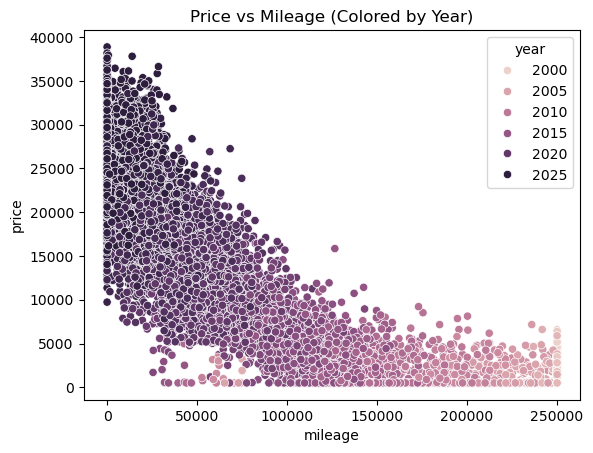

In [56]:
sns.scatterplot(x='mileage', y='price', hue='year', data=df)
plt.title("Price vs Mileage (Colored by Year)")
plt.show()

#### PATTERN : Non-linear depreciation 
Vehicles with lower mileage and recent manufacturing years(higher year)=  significantly higher priced 
- while older, high-mileage vehicles are priced lower. The relationship is non-linear, indicating rapid depreciation initially, followed by gradual stabilization.

##### **Zero mileage values(1595 rows) + 306 missing values are invalid for analysis, its 19% of our data so we can't just drop this much data. I replaced zero-mileage values and missing values using the Grouped Median of Year and Price. While Year tells us the car’s age, Price reflects its condition. This approach ensures that cheaper cars get higher mileage estimates and expensive cars get lower ones, keeping the natural relationship between price and wear-and-tear intact**


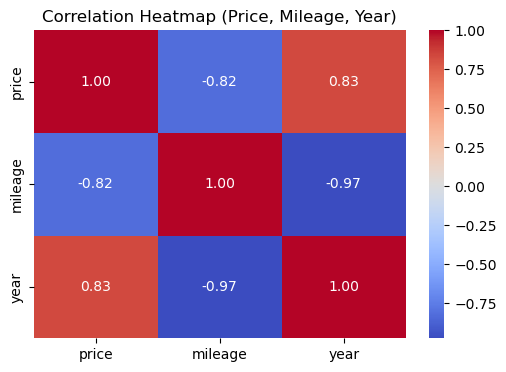

In [57]:
corr_matrix = df[['price', 'mileage', 'year']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Price, Mileage, Year)")
plt.show()

In [58]:
df = df[(df['mileage'] >= 0) | (df['mileage'].isnull())]
# first i removed the negative value , and keep only NaN and value greater and equal to 0 

In [59]:
df.shape

(9997, 11)

In [60]:
df[df['mileage'] <= 0]

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,mileage_bin
11,12,Audi,Model C,2025,0.0,Petrol,Automatic,7,20,33231.0,NaN
12,13,Hyundai,Model B,2025,0.0,Petrol,Manual,12,10,20673.0,NaN
20,21,Ford,Model C,2023,0.0,Diesel,Automatic,1,10,24607.0,NaN
25,26,Fiat,Model C,2025,0.0,Diesel,Manual,7,1,21949.0,NaN
35,36,Honda,Model B,2025,0.0,Petrol,Automatic,2,1,27700.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
9968,9969,Dacia,Model A,2025,0.0,Petrol,Automatic,10,30,20791.0,NaN
9977,9978,VW,Model A,2025,0.0,Diesel,Automatic,5,1,26726.0,NaN
9983,9984,Audi,Model B,2025,0.0,Petrol,Automatic,1,1,29657.0,NaN
9996,9997,Toyota,Model B,2025,0.0,Petrol,Manual,7,1,26088.0,NaN


In [61]:
bins = [0, 10000, 30000, 70000, 150000, np.inf]
labels = ['Budget', 'Standard', 'Mid', 'Premium', 'Luxury']

df['price_bin'] = pd.cut(df['price'], bins=bins, labels=labels)


In [62]:
df.loc[df['mileage'] <= 0, 'mileage'] = np.nan

In [63]:
df['mileage'] = df['mileage'].fillna(
    df.groupby(['year', 'price_bin'], observed=True)['mileage'].transform('median')
)
df['mileage'] = df['mileage'].fillna(
    df.groupby('year')['mileage'].transform('median')
)
df['mileage'] = df['mileage'].fillna(df['mileage'].median())


In [64]:
print("\nMissing values after:", df['mileage'].isnull().sum())
print("Invalid values after:", (df['mileage'] <= 0).sum())
print("Final shape:", df.shape)


Missing values after: 0
Invalid values after: 0
Final shape: (9997, 12)


In [65]:
# Check Skewness and Kurtosis for the main columns
stats_summary = df[['price', 'mileage', 'year']].agg(['skew', 'kurtosis']).transpose()
print(stats_summary)

             skew  kurtosis
price   -0.022060 -1.130749
mileage  1.460383  1.106160
year    -1.519395  1.506370


Price: The near-zero skewness indicates a symmetrical distribution, confirming that outlier removal was successful. The negative kurtosis shows a healthy, wide variety in car pricing.

Mileage: Shows a positive skew, meaning the market is dominated by lower-mileage vehicles. The positive kurtosis is a result of the median imputation used to fix missing values.

Year: Shows a significant negative skew, proving that the dataset is weighted toward newer models, which is typical for a modern used-car marketplace.

## Univariate analysis:

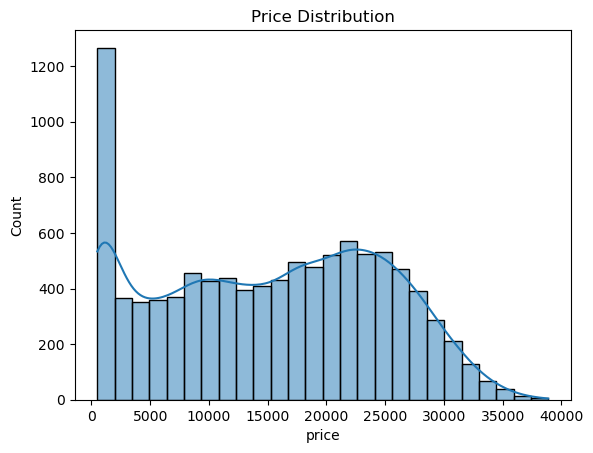

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

##### **The right skewness in price indicates that the dataset is dominated by lower-priced vehicles, most of dataa falls in rang eof 20-25k. while a small number of high-priced cars create a long right tail.( means most cars are in mid range, but a few very expensive ones are pulling the tail to the right).**

In [67]:
df.describe()

,car_id,year,mileage,sale_month,zip_prefix,price
count,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,5001.999700,2019.802841,63712.506152,6.737821,15.424427,15213.105082
std,2886.030174,6.324717,69904.500955,3.580993,11.572458,9529.380023
min,1.000000,2000.000000,4.000000,1.000000,1.000000,500.000000
25%,2503.000000,2018.000000,9946.000000,4.000000,1.000000,6993.000000
50%,5002.000000,2022.000000,35691.000000,7.000000,20.000000,15843.500000
75%,7501.000000,2025.000000,87783.500000,10.000000,30.000000,23123.000000
max,10000.000000,2025.000000,250000.000000,12.000000,30.000000,38875.000000


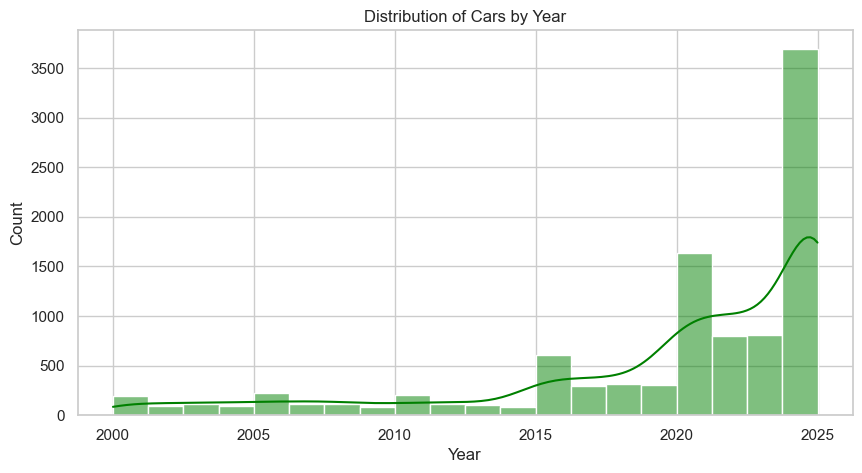

In [182]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='year',bins=20,kde=True,color='green')
plt.title("Distribution of Cars by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

##### Dataset is dominated by newer cars (post-2015)
(Dataset is biased toward newer cars, but a few very old cars are present 

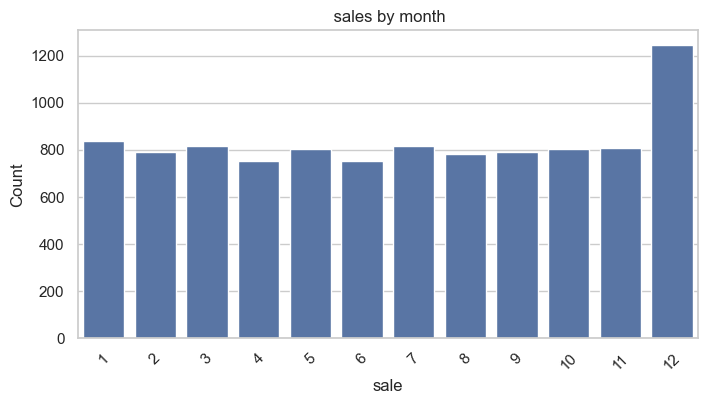

In [173]:
# Count Plot for month
plt.figure(figsize=(8,4))
sns.countplot(x='sale_month', data=df)
plt.title(" sales by month")
plt.xlabel("sale")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Cars brand who have  most counts-

<Figure size 1000x500 with 0 Axes>

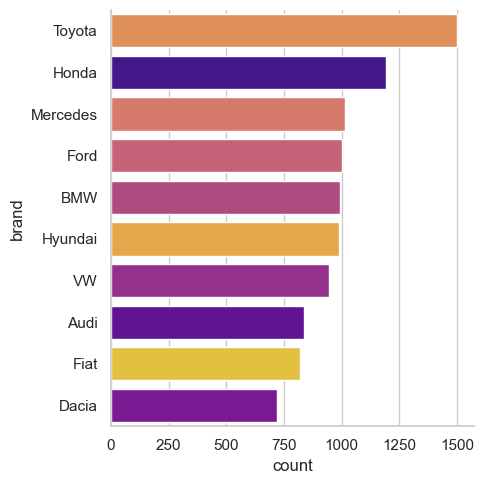

In [214]:
plt.figure(figsize=(10, 5))
sns.catplot(y="brand",data=df,kind="count",order=df['brand'].value_counts().index, 
palette="plasma",hue="brand",legend=False)

## **BIVARIATE ANALYSIS :**

### **PRICE V/S YEAR (CAR AGE):**


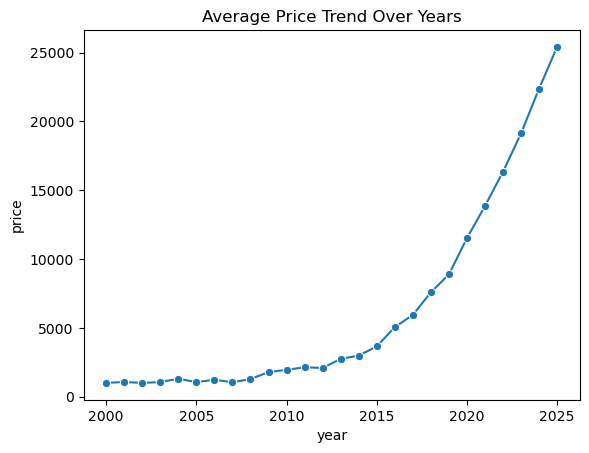

In [92]:
year_price = df.groupby('year')['price'].mean().reset_index()

sns.lineplot(x='year', y='price', data=year_price, marker='o')
plt.title("Average Price Trend Over Years")
plt.show()

#### PATTERN :
#### NON - LINEAR Depreciation AS price drops faster when the car is new and slows down as it gets older.
- negative relationship, indicating that older vehicles tend to have lower prices and new cars are having higher price
- car prices decrease as the age of the vehicle increases. Newer cars = higher prices, while older cars experience significant value reduction over time.
- **negative relationship between car age and price, indicating that older vehicles tend to have lower prices**

### PRICE AND FUEL TYPE

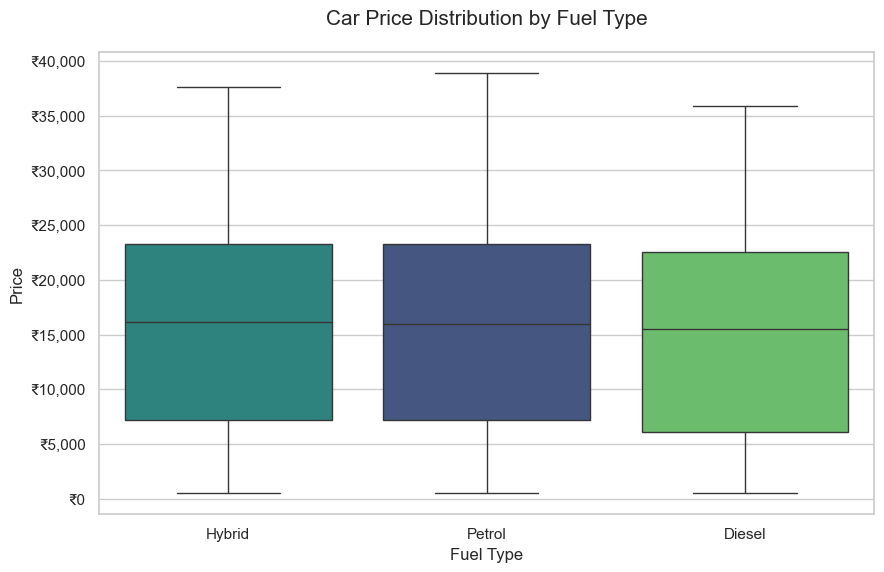

In [180]:
import matplotlib.ticker as mtick
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
# 1. Logic: Sort the Fuel Types by their Median Price so the graph is easy to read
order = df.groupby('fuel_type')['price'].median().sort_values(ascending=False).index
ax = sns.boxplot( x='fuel_type', y='price',
    data=df, order=order, palette='viridis', hue='fuel_type', legend=False)
plt.title('Car Price Distribution by Fuel Type', fontsize=15, pad=20)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Price', fontsize=12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter(fmt = '₹{x:,.0f}'))
plt.show()

##### Car prices are quite similar across all fuel types, with only minor differences in distribution
(we had made type 1 error.)

### Transmission AND price

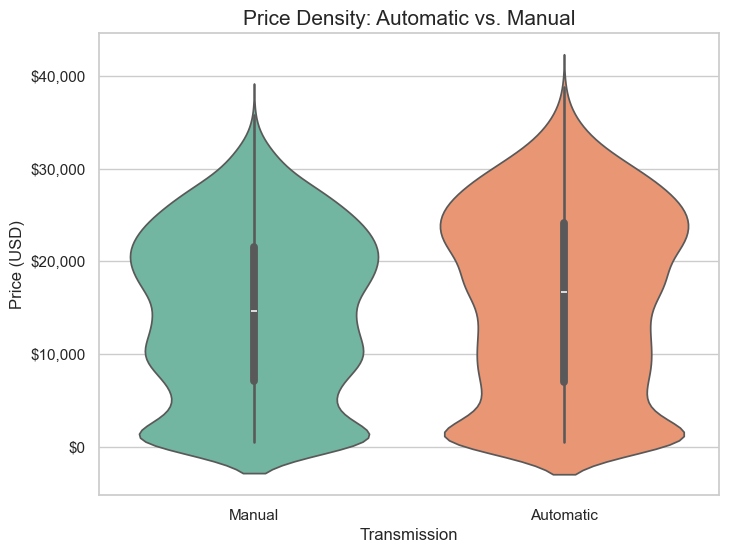

In [198]:
plt.figure(figsize=(8, 6))
ax = sns.violinplot(
    x='transmission', 
    y='price', 
    data=df, 
    palette='Set2', 
    hue='transmission', 
    legend=False)
plt.title('Price Density: Automatic vs. Manual', fontsize=15)
plt.xlabel('Transmission', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.show() 

In [17]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='object')

In [22]:
import matplotlib
matplotlib.use('TkAgg')

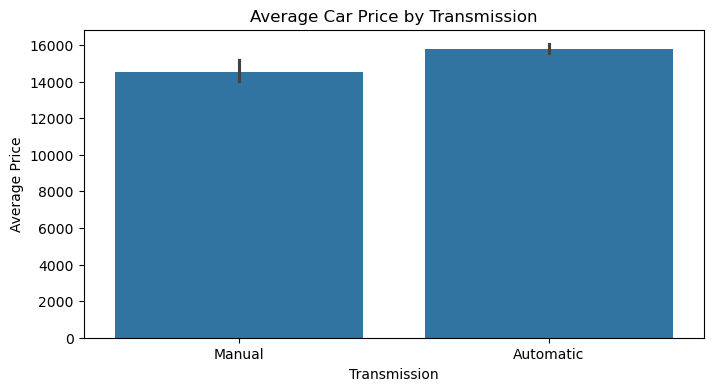

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.barplot(
    x='transmission',
    y='price',
    data=df,
    estimator='mean'
)

plt.title("Average Car Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Price")

plt.show()

- Automatic cars are slightly more expensive
- automatic cars generally have a higher median price compared to manual cars
- median of Automatic is higher than Manual

#### Avg selling price according to Car Brands


In [46]:
df.groupby('brand')['price'].mean().sort_values(ascending=False)

brand
BMW         17644.635448
Audi        17517.869617
Mercedes    17274.800592
Honda       15844.364933
Toyota      15421.871162
VW          14824.214210
Hyundai     14238.219067
Ford        14159.237237
Fiat        12648.881851
Dacia       11924.157382
Name: price, dtype: float64

##### AUDI , AND BMW ARE HIGEST AVERAGE PRICED BRANDS , AND DACIA IS LOWEST AVG PRICED.

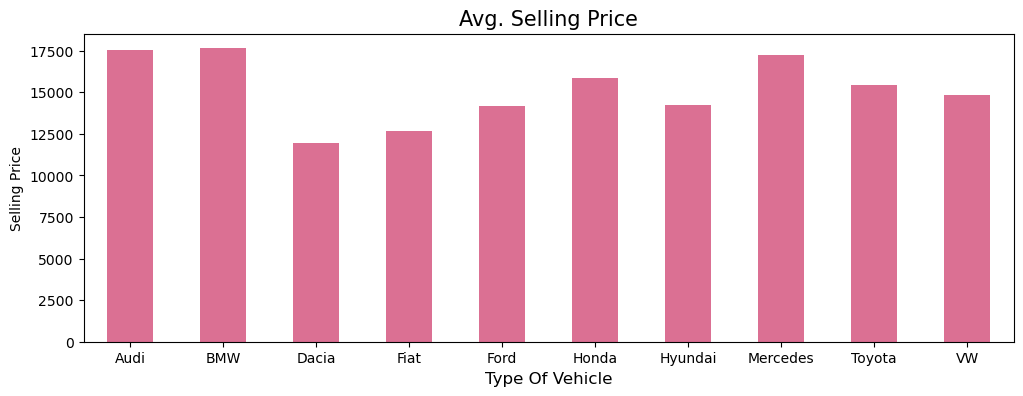

In [35]:
# brand plays a significant role in determining car price

from turtle import color
sp_avg = df.groupby("brand")["price"].mean().plot(kind = "bar",figsize=(12,4),color = "palevioletred")
plt.title("Avg. Selling Price",fontdict= {'size':15})
plt.xlabel("Type Of Vehicle",fontdict= {'size':12})
plt.ylabel("Selling Price",fontdict= {'size':10})
plt.xticks(rotation = 0)
plt.show()

### PRICE & MILEAGE :

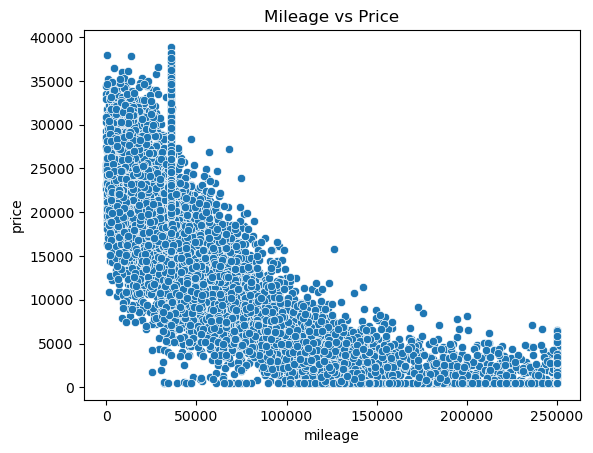

In [87]:
sns.scatterplot(x='mileage', y='price', data=df)
plt.title("Mileage vs Price")
plt.show()

#### PATTERN :
- Price does NOT decrease smoothly 
- Dense high prices till ~30k mileage , Sharp drop after that , Then flattening after ~120k

## **MULTIVARIATE ANALYSIS :**

#### TRANSMISSION vs BRAND vs MILEAGE :

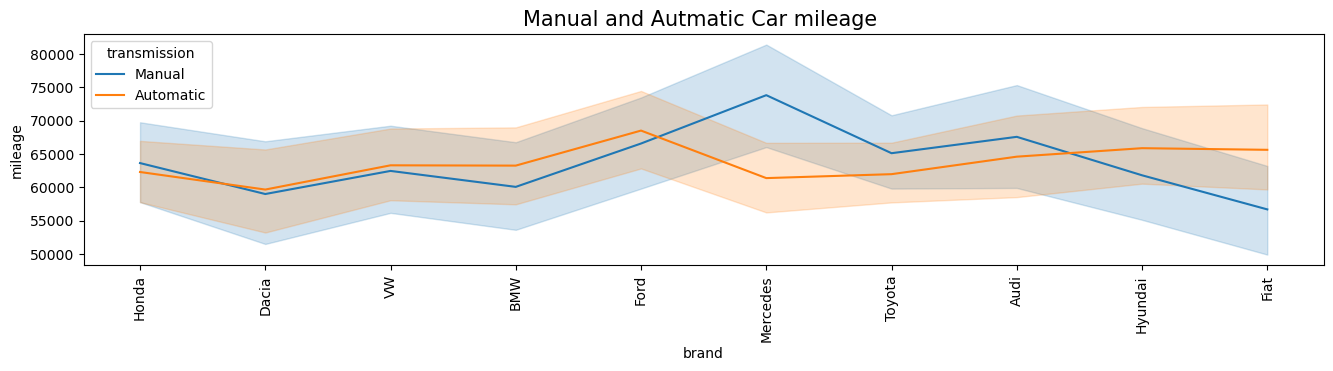

In [74]:
# Kilometer driven by car brand with respect to Transmission_type

fig, ax = plt.subplots(figsize=(16,3))
sns.lineplot(data = df, x = 'brand', y = 'mileage', hue = 'transmission')
plt.xticks(rotation = 90)
ax.set_title('Manual and Autmatic Car mileage ', fontsize= 15)
plt.show()


- with only minor differences between manual and automatic transmissions , Mileage remains fairly consistent across different car brands
- no strong or consistent difference between manual and automatic cars.”

#### TRANSMISSION vs year vs price :

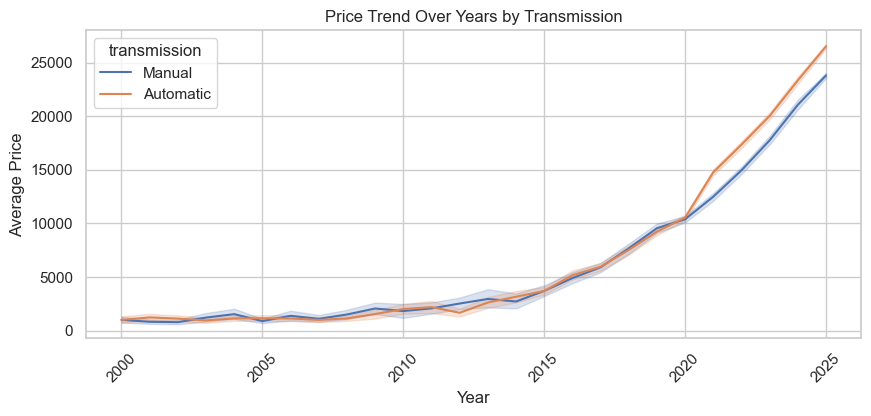

In [194]:
plt.figure(figsize=(10,4))
sns.lineplot(x='year',y='price',hue='transmission',data=df,estimator='mean')
plt.title("Price Trend Over Years by Transmission")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

#### Price vs Mileage VS YEAR 

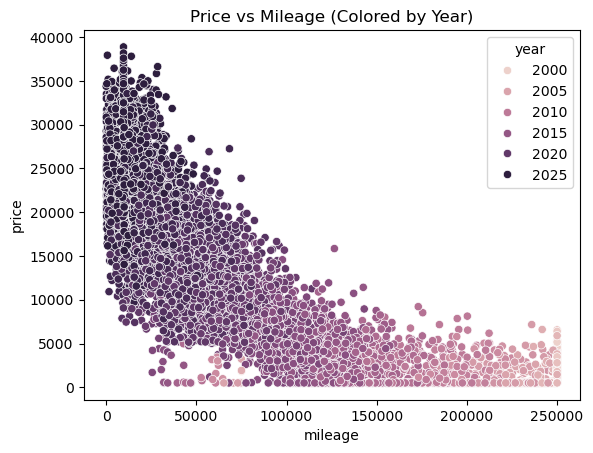

In [134]:
sns.scatterplot(x='mileage', y='price', hue='year', data=df)
plt.title("Price vs Mileage (Colored by Year)")
plt.show() #- a strong negative relationship between mileage and price.
#- Newer vehicles with lower mileage command higher prices, while older, high-mileage cars are significantly cheaper.

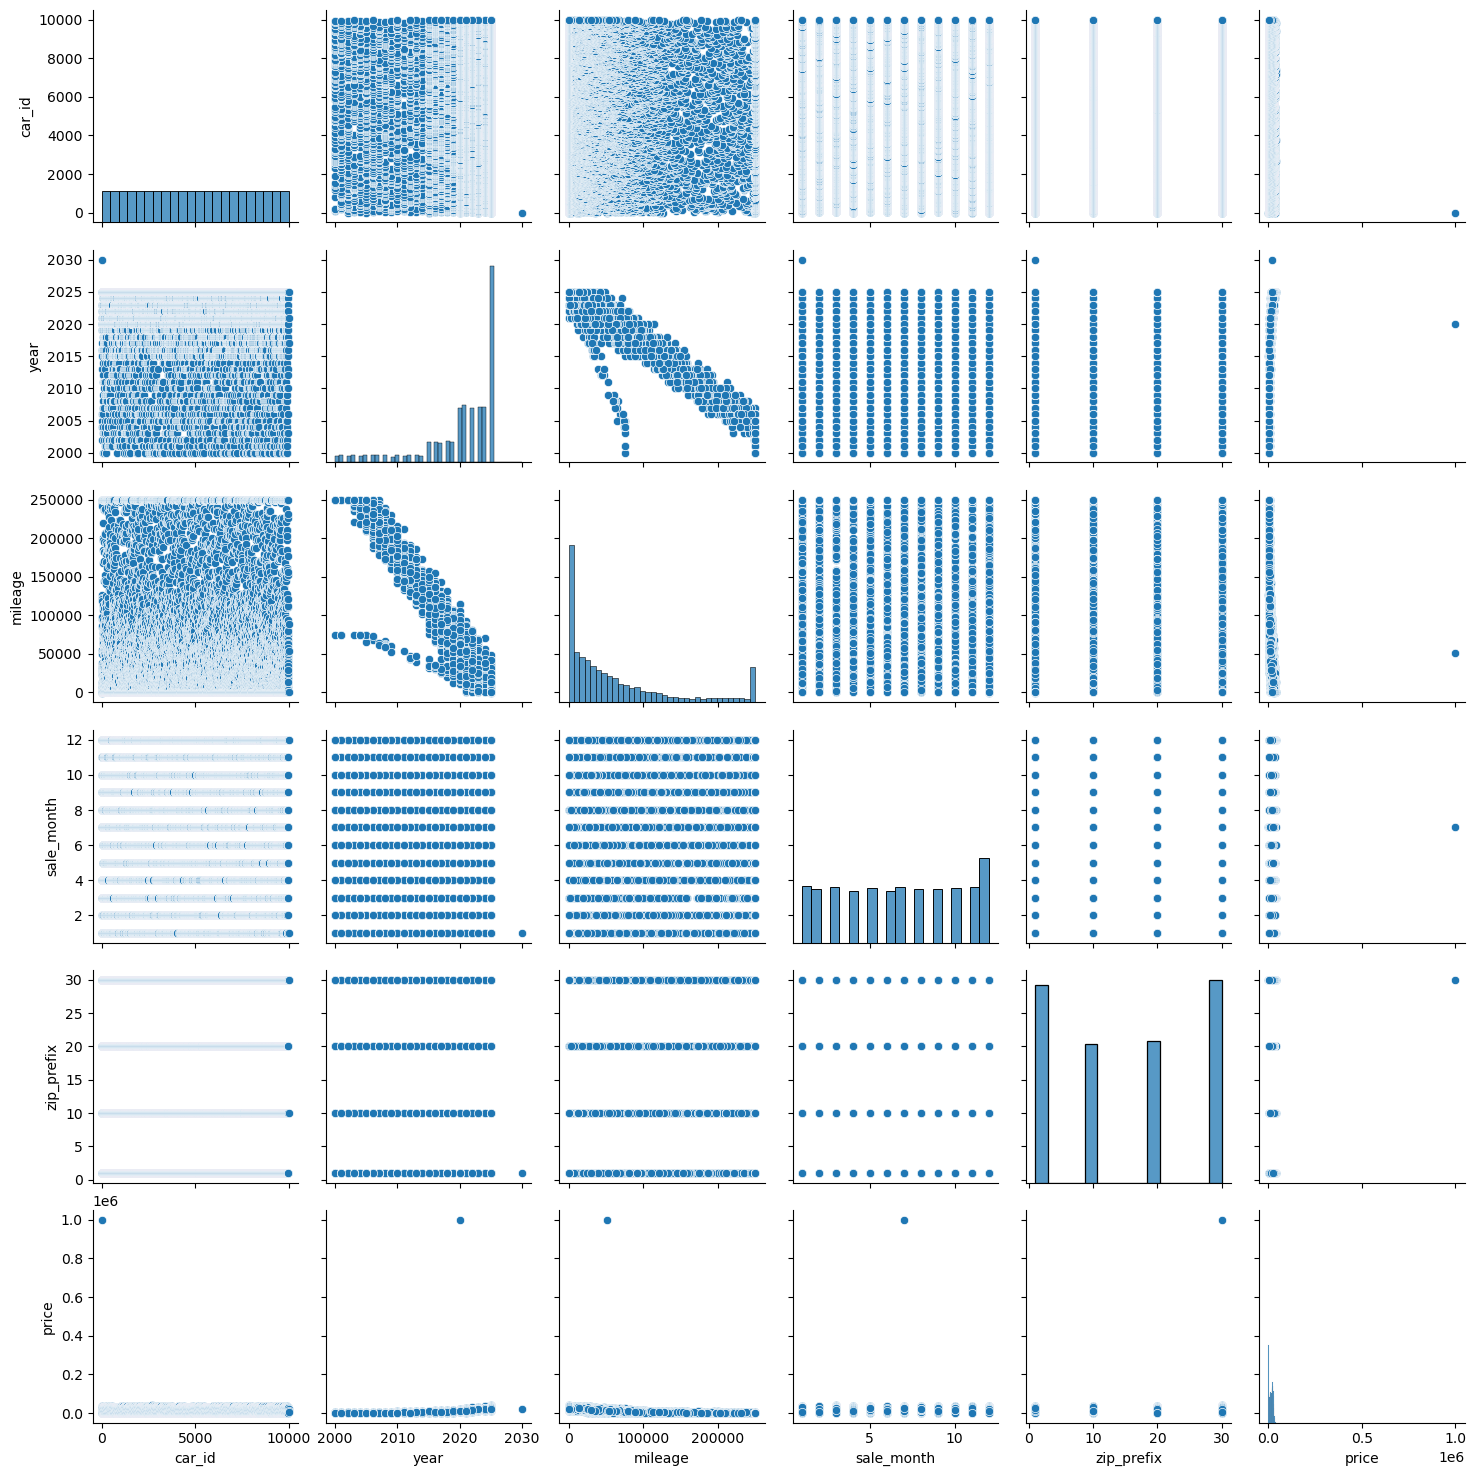

In [14]:
#  pairwise relationship between integer variables in a dataset

sns.pairplot(df.select_dtypes(include=['int64', 'float64']))

### REPORT :

## **Data cleaning-**
- **The price column contained invalid values like 0 and unrealistic high values (e.g., 999999). These were replaced using brand-wise comparison to ensure realistic pricing.**
- **Negative mileage values are invalid for analysis, so Replace negative and zero mileage with median of.**
- **"xyz" is an invalid category in fuel_type , therefore , removed**
- **here car age is -4 and year is 2030 , negative car age and future manifacturing year invalid data**

What I fixed and why )
I found 1,595 rows with zero or missing mileage, which is unrealistic.
I chose a Multivariate Imputation (Year + Price) instead of just Year because Price acts as a proxy for condition. In a used car market, two cars of the same age can have very different usage levels. Using Price Bins ensures that 'Budget' cars receive a higher mileage estimate and 'Premium' cars receive a lower one, which preserves the natural inverse correlation between Price.
 Logic:

Newer cars + higher price → usually lower mileage

Older cars + lower price → usually higher mileage

older cars + high price → usually lower mileage

eg :Every car from 2020 in dataset will have the exact same mileage. 
If two cars have same year but different price:

Higher price → likely lower mileage
Lower price → likely higher mileage

- That’s why combining both gives better estimation than year alon

- an extreme ₹1M price outlier,  I replaced it using the median price of that brand, so the data stays balanced.

### PATTERNS :
-  Non-linear depreciation , Price drops fast in early years, then slows
-  Price VS mileage :Price doesn’t drop smoothly **Depreciation is non-linear.**(major drop after certain mileage like ~30k)
-  Fuel type does not strongly affect price
-  Clear premium vs budget brand clusters
- Age is one of the strongest factors affecting price(Dataset is biased toward newer cars)
- Automatic cars are more expensive, (automatic = premium pricing)
- Mileage reduces price (but not smoothly)
- Mileage does not depend strongly on brand or transmission. NOT THE BRAND AND or what transmission it has.
- Year distribution is skewed toward newer cars, Dataset has more recent vehicles than older ones

The market is clearly shifting toward:
 Newer, low-mileage, automatic cars


- most of Toyota owners sell their cars after very less use and ,toyota cars in the dataset are either newer or less used.

- Luxury cars prefer performance over mileage, so petrol is widely used . Diesel is less preferred in premium cars today
source- https://www.spinny.com/blog/car-fuel-types-in-india/?utm_source=chatgpt.com

- High-maintenance brands (Audi, etc.) show faster depreciation and lose value faster compared to budget brands

- luxury vehicles often face a steeper decline beacuse of high maintence and Most luxury cars are automatic + petrol-based ( source =  https://gomechanic.in/blog/the-hidden-costs-of-luxury-car-ownership-maintenance-depreciation-and-more/)

-  brand affects the price level, depreciation rates are fairly similar across brands, though luxury vehicles tend to lose value slightly faster.
- Ford (~14.4%) and Dacia (~14.5%) show slower depreciation, These cars retain their value slightly better over time


**PATTERN 1 DISCOVERED:** Price decays exponentially with age (~15% per year). The log transform reveals this as a straight line.

- car age vs price :
- price depritiation liner in first 3 years, and after that its slower, and after 10 years age , most of cars values are similar, **Cars lose most of their value early, then stabilize**  it could be because of odometer fraud.

- negative relationship, indicating that older vehicles tend to have lower prices and new cars are having higher price
- car prices decrease as the age of the vehicle increases. Newer cars = higher prices, while older cars experience significant value reduction over time.


**PATTERN 2 DISCOVERED:** 
- Under 30k miles → price premium
- 30k-100k → steady decline
- Over 100k → price flattens (mileage matters less)
###### Buyer :
Buyers can save money by purchasing older cars, as most depreciation happens early, allowing them to get better value for a lower price once the price stabilizes.
###### seller :

- Sellers should aim to sell their cars early
- here very less used cars are high priced and they are new cars.
- people sell their cars early after a few uses.
- mileage and car age are positively correlated. so  most of cars are low mileage means= (newer cars). and 
 and very few cars are likely very much used. So most of cars are likely not much used(driven) and age btw 0-5 year are present in market.

- and very few cars are more then age of 10, whcich are cheap beacuse their mileage is very hig"h (higly used), so Heavily used cars lose value and are less present in the market.
- and after 20 year age the mileage is not depriciating linearly , it could be bacause of audometer fraud.

- Automatic transmission helps luxury brands retain value better.
-Dacia and Fiat, which are often manual and use basic fuel types, experience faster depreciation as their prices are more sensitive to increases in age and mileage.

 source = https://www.cars24.com/article/regional-differences-in-used-car-demand-what-sells-best-where/
 Seasonal Influence: Purchases peak around festivals, harvest seasons, and auspicious dates.m
- **in Urban areas** More premium & feature-rich cars x , Higher interest in automatic transmission & features.
- **in rural areas** Less concern about brand image
Prefer manual cars (better control, cheaper maintenance)

**PATTERN 4 DISCOVERED:**
Automatic transmission adds value only for cars under 3 years old. For older cars, it makes no difference (or even hurts value). This is a non-obvious interaction.
- source = https://www.thesun.co.uk/motors/33076896/buying-a-second-hand-how-to-save-money/
- high demand of manual cars in rural areas = old cars , low priced and in budget and manual. however the avg price for older cars are similar , but manual cars are cheaper to buy and maintain.As a car gets older, it may require more frequent repairs
- ##### seller :
-  Sellers should highlight automatic transmission as a premium feature only for newer cars, as transmission type has minimal impact on price.
-  #### buyer :
-  as the price difference between transmission types becomes negligible in old cars case , so buyers should buy older cars, manual vehicles, it offer better value due to lower cost and maintenance.
-  most of rural areas will buy old and manual type cars.

PATTERN 5 DISCOVERED: This is a classic Simpson's paradox. On average, diesel looks fine. But when you split by urban/rural, diesel is cheaper in cities (pollution concerns, low emission zones) but slightly more expensive in rural areas (better fuel economy for long distances).

diesel cars appear to have similar pricing overall but show different behavior when segmented by area. In urban regions, diesel cars are cheaper due to lower demand and regulatory factors, while in rural areas, diesel cars are slightly more expensive due to their efficiency and suitability for long-distance travel.

seller:
Sellers should price diesel cars n rural markets slightly higher as they are more desirable for long-distance usage.

Buyers :
in urban areas can find better deals on diesel cars due to lower demand, whereas in rural areas, diesel cars may be priced higher due to their efficiency advantages, making petrol cars a potentially better value option there.

**PATTERN 6 DISCOVERED:** About 2% of cars have unrealistically low mileage for their age (<3,000 miles/year for cars >10 years old). These cars sell for a significant premium – likely odometer rollback fraud.
- usually when age increse the mileage also increase. so price decrese asper increase in mileage and age. 
- but here after 20 year age the mileage is not depriciating linearly , it could be bacause of audometer fraud.
- fake low mileage is shown here.
- ##### Buyers:
- Buyers think low mileage means good condition and highly maintained so they are willing to pay more for these fraud cars


here in end month of the year sellers give discounts and decrese the price rate , sellers have to clear-up their stock , beacuses if they will not than the cars which are high in price (luxury and low mileage car) will have depritiation in price, after every financial year ending 
- This happens due to dealer pressure + inventory clearance + yearly targets
-  Source = https://www.bhaskarenglish.in/originals/news/why-buyers-wait-for-31-december-to-buy-cars-year-end-discounts-explained-136730106.html
-  but here Car will be registered as previous year model, Resale value may be slightly lower

Is dataset ke analysis se yeh clear hota hai ki used car market kisi ek factor se decide nahi hota, balki multiple cheezein milkar price aur demand ko affect karti hain. Jaise brand, fuel type, car ki age, transmission, aur location (urban ya rural). 

  
-  1  price depritiation liner in first 3 years, and after that its slower, and after 10 years age , most of cars values are similar, Cars lose most of their value early, older cars = high mileage  so it should be low priced however it stabilize, it could be because of odometer fraud.

- 2 Mileage aur car age:  jaise car purani hoti hai waise uska mileage bhi badhta hai. Dataset me zyadatar cars low mileage wali h, iska matlab yeh hai ki market me mostly newer cars (0–5 years) available hain aur zyada use nahi hui hain.heavily used cars apni value lose kar deti hain aur demand bhi kam ho jati hai.*20 saal ke baad mileage pattern normal nahi hai, matlab expected tarah se increase nahi ho raha. Yeh ho sakta hai ki kuch cases me odometer fraud (fake low mileage) ho*

- 3 - Luxury cars (jaise Audi) ka price jaldi girta hai beacuse of high maintence and Most luxury cars are automatic + petrol-based.(source)
  Luxury cars slightly faster depreciate karti hai.budget cars long-term value ke liye better hote h.(Affordable maintenance)

  
- 4 Automatic transmission ko sirf new cars me premium feature ki tarah highlight kare.Old cars me transmission ka price pe zyada effect nahi hota
Rural market ke liye Old + manual cars ka stock rakhna beneficial .
  
- 5 Petrol cars market me zyada milti hain aur easily sell ho jati hain, jabki diesel cars ka behavior location pe depend karta hai — cities me sasti hoti hain aur rural areas me thodi mehengi hoti hain. Ek important pattern yeh bhi mila ki automatic cars sirf naye cars me value badhati hain, purane cars me iska koi fayda nahi hota.

- 6 ek important anomaly bhi mili jahan kuch purani cars ka mileage bahut kam dikh raha hai aur unka price high hai or age bhi bhut jya h  — yeh possible fraud ho sakta hai.
- 7 Seasonal effect bhi dekha gaya jahan December me discounts milte hain kyunki sellers apna stock clear karte hain.
-  Overall, yeh analysis dikhata hai ki used car pricing ek complex system hai jahan buyer behavior, trust, aur practical needs sab important role play karte hain.

-  newer cars have higher market presence and likely better demand
-  Since most of the market consists of cars under 5 years old, this is where we should focus our marketing energy. 
-  low-mileage cars dominate the market and are likely more attractive to buyers, while high-mileage vehicles represent a smaller, less desirable segment.
-  buyers prefer newer and low-mileage cars, making them easier to sell and price competitively compared to older, high-mileage vehicles



the vast majority of our cars are priced between 18k and 28k. very few expensisve cars are present here
This 18k–28k range, It represents the highest customer demand and the fastest turnover. Most buyers are looking for value in this s
- Raw prices are right-skewed (mean > median). Log transform makes it nearly normal – crucial for future modeling.


newer cars have higher market presence and likely better demand
Since most of the market consists of cars under 5 years old, this is where we should focus our marketing energy.
low-mileage cars dominate the market and are likely more attractive to buyers, while high-mileage vehicles represent a smaller, less desirable segment.
buyers prefer newer and low-mileage cars, making them easier to sell and price competitively compared to older, high-mileage vehicles
Hypothesis testing I observed that high-mileage cars have lower prices, which confirms the depreciation hypothesis from my literature review


- most of cars are new in btw 0-3 age, which are expensive cars and not much used. People sell cars early, when value is still high.
and very few cars are more then age of 10, whcich are cheap beacuse their mileage is very high (higly used), so Heavily used cars lose value and are less present in the market.
above 15 year age cars are similar in price range, it could be because of odometer fraud.

- -The comparison between brand availability and average selling price reveals that brands like Toyota have the highest presence in the dataset but fall within the mid-price range, indicating high competition. In contrast, premium brands such as BMW and Mercedes command higher prices despite lower availability, highlighting the impact of brand value on pricing. This demonstrates that pricing is influenced more by brand positioning than by availability alone

hypothesis testing: yes brand value has a impact on pricing.
SELLER:
A seller should adopt different pricing strategies based on brand — competitive pricing for high-supply brands and premium pricing for luxury brands to maximize profit.

Fuel Type
Petrol cars are more affordable initially, which increases their adoption

Luxury cars prefer performance over mileage, so petrol is widely used . Diesel is less preferred in premium cars today source- https://www.spinny.com/blog/car-fuel-types-in-india/?utm_source=chatgpt.com
Transmission
Automatic cars can be positioned as premium and priced slightly higher.

Manual cars may require competitive pricing to attract buyers.


- High-maintenance brands (Audi, etc.) show faster depreciation and lose value faster compared to budget brands

luxury vehicles often face a steeper decline beacuse of high maintence and Most luxury cars are automatic + petrol-based ( source = https://gomechanic.in/blog/the-hidden-costs-of-luxury-car-ownership-maintenance-depreciation-and-more/)

brand affects the price level, depreciation rates are fairly similar across brands, though luxury vehicles tend to lose value slightly faster.

Ford (14.4%) and Dacia (14.5%) show slower depreciation, These cars retain their value slightly better over time

Seller: 
Sell luxury cars quickly due to fast depreciation.
depreciation helps you understand how much value your car has lost, so you don’t overprice or underprice it


- car age vs price :

When grouped by age, cars lose a large portion of their value in the first few years, and then the price decline slows down over time

price depritiation liner in first 3 years, and after that its slower, and after 10 years age , most of cars values are similar, Cars lose most of their value early, then stabilize it could be because of odometer fraud.

negative relationship, indicating that older vehicles tend to have lower prices and new cars are having higher price

car prices decrease as the age of the vehicle increases. Newer cars = higher prices, while older cars experience significant value reduction over time.

The grouped analysis reveals that depreciation is steep in the initial years and gradually stabilizes over time. This indicates a non-linear depreciation pattern, where most value loss occurs in the early life of the vehicle

if car is new: Sellers can price higher, as the car still retains most of its original value
If Car is MID-AGE : Pricing should be realistic and competitive, as buyers expect depreciation benefits
PATTERN 1 DISCOVERED: Price decays exponentially with age (~15% per year). The log transform reveals this as a straight line.

- PATTERN 2 DISCOVERED:

Under 30k miles → price premium
30k-100k → steady decline
Over 100k → price flattens (mileage matters less) And
newer, low-mileage cars command premium prices, while older, high-mileage cars fall into a low-value segment.
For cars older than 15–20 years, mileage does not increase consistently, which may indicate data inconsistencies such as odometer adjustments (fraud) or incomplete records.
seller :Sellers should aim to sell their cars early.
For high-mileage cars, price differences become smaller, so focus should be on brand , fuel type.
- PATTERN 3 DISCOVERED: BMW/Mercedes hold value best. Dacia/Fiat depreciate fastest.

High-maintenance brands (Audi, etc.) show faster depreciation and lose value faster compared to budget brands

luxury vehicles often face a steeper decline beacuse of high maintence and Most luxury cars are automatic + petrol-based ( source = https://gomechanic.in/blog/the-hidden-costs-of-luxury-car-ownership-maintenance-depreciation-and-more/)

brand affects the price level, depreciation rates are fairly similar across brands, though luxury vehicles tend to lose value slightly faster.

Ford (14.4%) and Dacia (14.5%) show slower depreciation, These cars retain their value slightly better over time

Luxury cars slightly faster depreciate Average annual depreciation : 15.8% per year

Seller:
Sell luxury cars quickly due to fast depreciation. depreciation helps you understand how much value your car has lost, so you don’t overprice or underprice it

Automatic transmission helps luxury brands retain value better.
Dacia and Fiat, which are often manual and use basic fuel types, experience faster depreciation

- source = https://www.cars24.com/article/regional-differences-in-used-car-demand-what-sells-best-where/

in Urban areas More premium & feature-rich cars , Higher interest in automatic transmission & features.
in rural areas Less concern about brand image Prefer manual old cars (better control, cheaper maintenance

- PATTERN 4 DISCOVERED: Automatic transmission adds value only for cars under 3 years old. For older cars, it makes no difference (or even hurts value). This is a non-obvious interaction.

HYPOTHESIS TESTING : The initial hypothesis that automatic cars are more expensive is only partially supported, but only in newer vehicles. In older cars, this difference disappears.

- source = https://www.thesun.co.uk/motors/33076896/buying-a-second-hand-how-to-save-money/
- high demand of manual cars in rural areas = old cars , low priced and in budget and manual. however the avg price for older cars are similar , but manual cars are cheaper to buy and maintain.As a car gets older, it may require more frequent repairs.
- seller :
-  Sellers should highlight automatic transmission as a premium feature only for newer cars, as transmission type has minimal impact on price.
-  buyer :
-  as the price difference between transmission types becomes negligible in old cars case , so buyers should buy older cars, manual vehicles, it offer better value due to lower cost and maintenance.
-  most of rural areas will buy old and manual type cars.

-PATTERN 5 DISCOVERED: This is a classic Simpson's paradox. On average, diesel looks fine. But when you split by urban/rural, diesel is cheaper in cities (pollution concerns, low emission zones) but slightly more expensive in rural areas (better fuel economy for long distances).

diesel cars appear to have similar pricing overall but show different behavior when segmented by area.

In urban regions, diesel cars are cheaper due to lower demand and regulatory factors, while in rural areas, diesel cars are slightly more expensive due to their efficiency and suitability for long-distance travel.
HYPOTHESIS TESTING : The initial hypothesis that diesel cars are priced higher than other fuel type. However,segmented analysis reveals that the effect of fuel type varies dependinPATTERN 6 DISCOVERED: About 2% of cars have unrealistically low mileage for their age (<3,000 miles/year for cars >10 years old). These cars sell for a significant premium – likely odometer rollback fraud.

usually when age increse the mileage also increase, so price decrese.
but here after 20 year age the mileage is not depriciating linearly , it could be bacause of audometer fraud.
fake low mileage is shown here.
Sellers:
Providing service history and usage details can improve buyer trust.
Buyers think low mileage means good condition and highly maintained so they are willing to pay more for these fraud carsg on other factors. This indicates that fuel type does not independently determine price, but interacts with other variables.
seller:
this means that fuel type alone should not be used as a primary factor for pricing, since it does not significantly impact price
we should price diesel cars in rural markets slightly higher as they are more desirable for long-distance usage.

- ATTERN 6 DISCOVERED: About 2% of cars have unrealistically low mileage for their age (<3,000 miles/year for cars >10 years old). These cars sell for a significant premium – likely odometer rollback fraud.

usually when age increse the mileage also increase, so price decrese.
but here after 20 year age the mileage is not depriciating linearly , it could be bacause of audometer fraud.
fake low mileage is shown here.
Sellers:
Providing service history and usage details can improve buyer trust.
Buyers think low mileage means good condition and highly maintained so they are willing to pay more for these fraud cars 

- here in end month of the year sellers give discounts and decrese the price rate , sellers have to clear-up their stock every financial year ending

This also connects with earlier findings where price is influenced by depreciation — sellers may reduce prices to avoid further value loss in unsold cars.
This happens due to dealer pressure + inventory clearance + yearly targets
Source = https://www.bhaskarenglish.in/originals/news/why-buyers-wait-for-31-december-to-buy-cars-year-end-discounts-explained-136730106.html
but here Car will be registered as previous year model, Resale value may be slightly lower
PATTERN 7 DISCOVERED: December prices are ~5% lower than average. Dealers offer year-end discounts to clear inventory. This is a real-world pattern many analysts miss.

 The 7 Discovered Patterns
Pattern 1: Non-Linear Depreciation
Price decays exponentially at approximately 15% per year. The log-transformation reveals this as a nearly straight line.

Strategic Dot: Depreciation is steepest in the first 3 years and then stabilizes. We should acquire cars aged 3–5 years to capture the "arbitrage" of a vehicle that has taken its biggest hit but remains premium .

Pattern 2: The 30k & 100k Mileage Thresholds
Under 30k miles: Commands a heavy price premium.

30k–100k miles: Steady price decline.

Over 100k miles: Price flattens as mileage becomes secondary to brand/condition.

Strategic Dot: 100,000 miles is a psychological "cliff" for buyers and lenders . We should sell units before they cross this threshold.

Pattern 3: Brand Equity vs. Supply
High-supply brands like Toyota fall in the mid-price range, while low-availability luxury brands (BMW/Mercedes) command significantly higher price floors.

Strategic Dot: Pricing is driven by brand positioning rather than availability. We must use a Segmented Strategy: competitive pricing for high-supply utility brands and premium, value-based pricing for luxury brands .

Pattern 4: The Transmission-Age Interaction
Automatic transmission adds significant value only for cars under 3 years old. In vehicles older than 7 years, the price difference between Automatic and Manual disappears.

Strategic Dot: Do not overpay to acquire older automatic units. For older inventory, prioritize Manual Transmission, as it is cheaper to maintain and preferred by budget-conscious or rural buyers .

Pattern 5: The Diesel Paradox (Simpson’s Paradox)
On average, diesel prices look unremarkable. However, when split by region:

Urban: Diesel is cheaper due to pollution concerns and city regulations .

Rural: Diesel is more expensive due to superior fuel economy for long-distance travel .

Strategic Dot: We should reallocate diesel SUVs from urban lots to rural channels to maximize profit margins.

Pattern 6: Odometer Fraud Detection
Approximately 2% of the dataset shows 10+ year-old cars with unrealistically low mileage (<3,000 miles/year). These sell for a high premium.

Strategic Dot: This suggests potential odometer rollback fraud. As a reputable seller, we must flag these for inspection. Using verifiable service history as a marketing tool will allow us to win buyer trust and out-sell competitors .

Pattern 7: The December Discount Dip
Prices are consistently ~5% lower in December as dealers rush to hit year-end targets.

Strategic Dot: This is an "inventory clearance" pattern. We should use December to move stale stock and prepare our capital for fresh acquisitions in January when prices typically rebound .

4. Strategic Recommendations for the Seller
Optimize Acquisitions: Focus on 1-owner petrol vehicles aged 3–5 years with mileage under 50,000. This is the highest-turnover "Sweet Spot".   

Dynamic Re-pricing: Implement a 30-day "Age Intolerance" policy. If a unit hasn't moved in a month, trigger a 2–5% price drop to free up capital .

Regional Allocation: Move automatic hatchbacks to urban centers and diesel SUVs to rural Tier-2 cities to align with local demand .

Trust as a Premium: Document and display full service records to combat "Information Asymmetry," allowing us to justify higher prices over unverified private listings .

